Computing Collatz stopping times...


Computing sandbox stopping times...


Computing Markov null model...


fig9 done


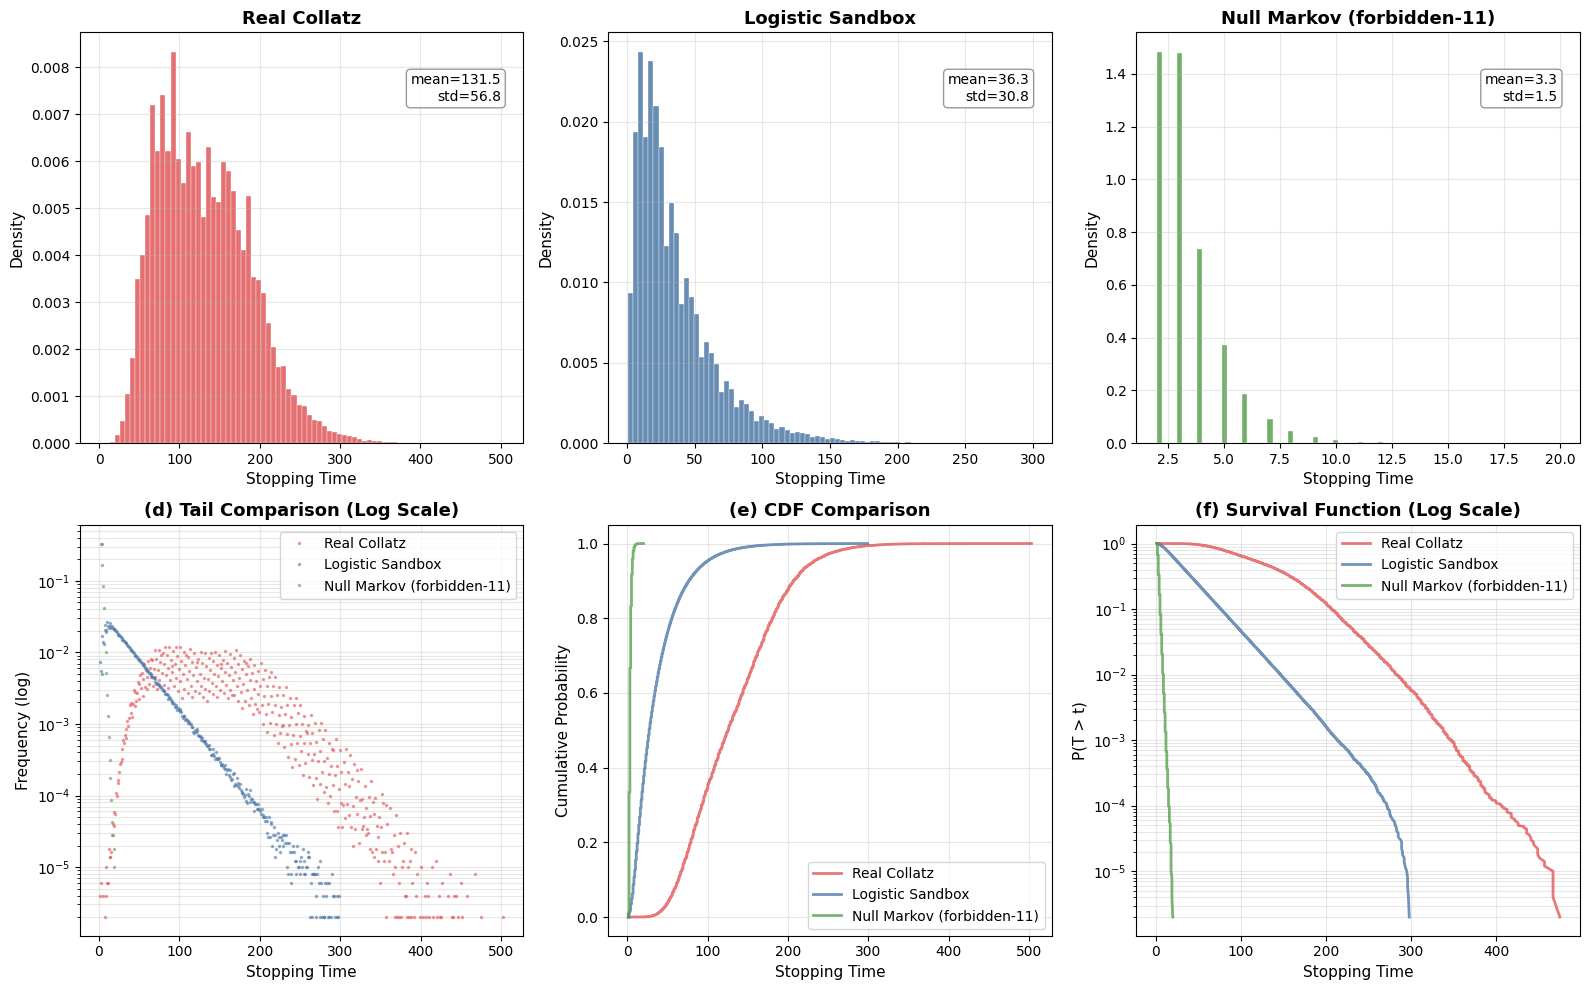

In [1]:
"""Fig 9: Null Markov model control experiment.
Compare stopping-time tails: real Collatz vs sandbox vs generic forbidden-11 Markov chain."""
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from numba import njit

MU = 1.7548776662466927
X_STAR = (-1.0 + np.sqrt(1.0 + 4.0 * MU)) / (2.0 * MU)
TARGETS = np.array([0.0, 1.0, 1.0 - MU])

# --- 1. Null Markov model ---
def markov_stopping_times(n_samples, max_steps=500):
    times = np.full(n_samples, max_steps, dtype=np.int32)
    state = np.random.choice([0, 1], size=n_samples, p=[2/3, 1/3])
    pattern_buf = np.zeros((n_samples, 3), dtype=np.int8)
    target_pattern = np.array([0, 1, 0], dtype=np.int8)
    for t in range(max_steps):
        pattern_buf[:, 0] = pattern_buf[:, 1]
        pattern_buf[:, 1] = pattern_buf[:, 2]
        pattern_buf[:, 2] = state
        if t >= 2:
            match = np.all(pattern_buf == target_pattern, axis=1)
            newly_done = match & (times == max_steps)
            times[newly_done] = t
        next_state = np.zeros(n_samples, dtype=np.int32)
        is_0 = state == 0
        next_state[is_0] = np.random.choice([0, 1], size=np.sum(is_0))
        next_state[~is_0] = 0
        state = next_state
    return times[times < max_steps]

# --- 2. Sandbox stopping times ---
def sandbox_stopping_times(n_samples, max_steps=300, eps=1e-4):
    times = np.zeros(n_samples, dtype=np.int32)
    x = np.random.uniform(-1, 1, n_samples)
    active = np.ones(n_samples, dtype=bool)
    for t in range(max_steps):
        if not np.any(active):
            break
        d = np.min(np.abs(x[active, None] - TARGETS[None, :]), axis=1)
        converged = d < eps
        idx = np.where(active)[0]
        times[idx[converged]] = t
        active[idx[converged]] = False
        x[active] = 1.0 - MU * x[active]**2
    return times[times > 0]

# --- 3. Real Collatz ---
@njit
def collatz_times(nums):
    res = np.zeros(len(nums), dtype=np.int32)
    for i in range(len(nums)):
        n = nums[i]
        s = 0
        while n > 1:
            if n % 2 == 0:
                n = n // 2
            else:
                n = 3 * n + 1
            s += 1
        res[i] = s
    return res

N = 500000
print("Computing Collatz stopping times...")
collatz_st = collatz_times(np.random.randint(1, 10**6, size=N, dtype=np.int64))
print("Computing sandbox stopping times...")
sandbox_st = sandbox_stopping_times(N)
print("Computing Markov null model...")
markov_st = markov_stopping_times(N)

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Individual histograms (linear scale)
datasets = [(collatz_st, 'Real Collatz', '#E15759'),
            (sandbox_st, 'Logistic Sandbox', '#4E79A7'),
            (markov_st, 'Null Markov (forbidden-11)', '#59A14F')]
for i, (data, label, color) in enumerate(datasets):
    axes[0, i].hist(data, bins=80, density=True, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(label, fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('Stopping Time', fontsize=11)
    axes[0, i].set_ylabel('Density', fontsize=11)
    axes[0, i].grid(True, alpha=0.3)
    mu_val = np.mean(data)
    std_val = np.std(data)
    axes[0, i].text(0.95, 0.90, f'mean={mu_val:.1f}\nstd={std_val:.1f}',
                    transform=axes[0, i].transAxes, fontsize=10, ha='right', va='top',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

# Row 2 left: Overlaid log-scale tail
for data, label, color in datasets:
    bins = np.arange(data.min(), data.max()+1, 1)
    counts, edges = np.histogram(data, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    valid = counts > 0
    axes[1, 0].semilogy(centers[valid], counts[valid]/len(data), '.', color=color, alpha=0.5, markersize=3, label=label)
axes[1, 0].set_title('(d) Tail Comparison (Log Scale)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Stopping Time', fontsize=11)
axes[1, 0].set_ylabel('Frequency (log)', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, which='both')

# Row 2 middle: CDF comparison
for data, label, color in datasets:
    sorted_d = np.sort(data)
    cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
    axes[1, 1].plot(sorted_d, cdf, color=color, linewidth=2, alpha=0.8, label=label)
axes[1, 1].set_title('(e) CDF Comparison', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Stopping Time', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Row 2 right: Survival (1-CDF) log scale
for data, label, color in datasets:
    sorted_d = np.sort(data)
    surv = 1.0 - np.arange(1, len(sorted_d)+1) / len(sorted_d)
    valid = surv > 1e-6
    axes[1, 2].semilogy(sorted_d[valid], surv[valid], color=color, linewidth=2, alpha=0.8, label=label)
axes[1, 2].set_title('(f) Survival Function (Log Scale)', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Stopping Time', fontsize=11)
axes[1, 2].set_ylabel('P(T > t)', fontsize=11)
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig9.png', dpi=300)
print("fig9 done")
